# Approach 1: TF-IDF + Logistic Regression

This is our first baseline approach. It scores each word in an article (TF-IDF) and learns which words point to which category. It ignores word order, so it shows how far keywords alone can go.

This notebook also creates the cleaning and the train/validation split (`split_ids.csv`) that all five models share.

## 1. Load the data
`Test.csv` has no labels, so we evaluate on a validation split taken from `Train.csv`.

In [1]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             ConfusionMatrixDisplay)

DATA_DIR = Path("../..")          # folder that holds Train.csv (change if yours is elsewhere)

train = pd.read_csv(DATA_DIR / "Train.csv")   # columns: id, content, category
print("Raw train shape:", train.shape)
train["category"].value_counts()

Raw train shape: (5151, 3)


category
Kitaifa      2000
michezo      1720
Biashara     1360
Kimataifa      54
Burudani       17
Name: count, dtype: int64

## 2. Clean the text
Fix the 255 `michezo` rows stored as Python lists (join their paragraphs) and drop rows with fewer than 3 words.

In [2]:
def clean_content(text):
    text = str(text).strip()
    # fix rows that look like "['para 1', 'para 2', ...]"
    if text.startswith("[") and text.endswith("]"):
        try:
            parts = ast.literal_eval(text)
            text = " ".join(str(p).strip() for p in parts)
        except (ValueError, SyntaxError):
            text = text.strip("[]").replace("', '", " ").strip("'")
    return " ".join(text.split())   # collapse extra whitespace

train["content"] = train["content"].apply(clean_content)
too_short = train["content"].str.split().apply(len) < 3
print("Dropping near-empty rows:", train.loc[too_short, "id"].tolist())
train = train[~too_short].reset_index(drop=True)

print("Rows still starting with '[':", train["content"].str.startswith("[").sum())
print("Clean train shape:", train.shape)

Dropping near-empty rows: ['SW4225', 'SW724', 'SW832']
Rows still starting with '[': 0
Clean train shape: (5148, 3)


## 3. Train/validation split
A stratified 80/20 split keeps every class in both parts. The IDs are saved to `split_ids.csv` so all models use the same rows.

In [3]:
train_ids, val_ids = train_test_split(
    train["id"], test_size=0.2, stratify=train["category"], random_state=42
)
split = pd.DataFrame({
    "id": pd.concat([train_ids, val_ids]),
    "split": ["train"] * len(train_ids) + ["val"] * len(val_ids),
})
split.to_csv("split_ids.csv", index=False)

df = train.merge(split, on="id")
train_df, val_df = df[df.split == "train"], df[df.split == "val"]
pd.crosstab(df["category"], df["split"])

split,train,val
category,,
Biashara,1087,272
Burudani,13,3
Kimataifa,43,11
Kitaifa,1600,400
michezo,1375,344


## 4. Tune the model
We try 8 settings with 5-fold cross-validation on the training part only:
- `C`: how strongly the weights are kept small (smaller = simpler model)
- `ngram_range`: single words, or single words + word pairs

`class_weight="balanced"` makes mistakes on the small classes cost more. We pick the setting with the best **macro-F1**, which counts all five classes equally.

In [4]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000)),
])
grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1, 10, 100],
}
search = GridSearchCV(pipe, grid, scoring="f1_macro",
                      cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1)
search.fit(train_df["content"], train_df["category"])

cv = pd.DataFrame(search.cv_results_)[["param_tfidf__ngram_range", "param_clf__C",
                                       "mean_test_score", "std_test_score"]]
print("Best settings:", search.best_params_)
cv.sort_values("mean_test_score", ascending=False).round(3)

Best settings: {'clf__C': 1, 'tfidf__ngram_range': (1, 1)}


,param_tfidf__ngram_range,param_clf__C,mean_test_score,std_test_score
2,"(1, 1)",1.0,0.650,0.076
0,"(1, 1)",0.1,0.628,0.057
6,"(1, 1)",100.0,0.625,0.068
4,"(1, 1)",10.0,0.625,0.070
1,"(1, 2)",0.1,0.614,0.058
3,"(1, 2)",1.0,0.577,0.060
7,"(1, 2)",100.0,0.573,0.064
5,"(1, 2)",10.0,0.572,0.065


**Result:** the best setting is `C=1` with single words. Adding word pairs made every setting worse, probably because it adds many rare features that ~4k training articles cannot support.

## 5. Validation results

In [5]:
model = search.best_estimator_
val_pred = model.predict(val_df["content"])

print(f"Validation macro-F1: {f1_score(val_df['category'], val_pred, average='macro'):.3f}")
print(f"Validation accuracy: {accuracy_score(val_df['category'], val_pred):.3f}")
print()
print(classification_report(val_df["category"], val_pred, digits=3))

Validation macro-F1: 0.633
Validation accuracy: 0.874

              precision    recall  f1-score   support

    Biashara      0.819     0.868     0.843       272
    Burudani      0.000     0.000     0.000         3
   Kimataifa      0.625     0.455     0.526        11
     Kitaifa      0.851     0.843     0.847       400
     michezo      0.958     0.936     0.947       344

    accuracy                          0.874      1030
   macro avg      0.651     0.620     0.633      1030
weighted avg      0.874     0.874     0.873      1030



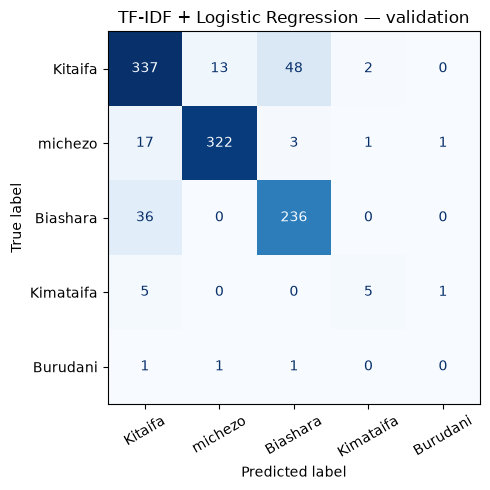

In [6]:
labels = ["Kitaifa", "michezo", "Biashara", "Kimataifa", "Burudani"]
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(val_df["category"], val_pred, labels=labels,
                                        cmap="Blues", ax=ax, colorbar=False)
ax.set_title("TF-IDF + Logistic Regression — validation")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Result:** accuracy is high (0.874), but macro-F1 is only 0.633. The three large classes score F1 ≥ 0.84, but the model misses all 3 `Burudani` articles and 6 of the 11 `Kimataifa` ones. With only 3 `Burudani` articles, that class's score is very noisy.

## 6. What did the model learn?
The 12 words with the largest weight for each category:

In [7]:
vocab = np.array(model.named_steps["tfidf"].get_feature_names_out())
clf = model.named_steps["clf"]
top = {cls: vocab[np.argsort(clf.coef_[i])[::-1][:12]] for i, cls in enumerate(clf.classes_)}
pd.DataFrame(top)

,Biashara,Burudani,Kimataifa,Kitaifa,michezo
0,biashara,brown,rais,magufuli,timu
1,uwekezaji,mwanamuziki,huawei,wananchi,mchezo
2,wafanyabiashara,google,kiongozi,serikali,klabu
3,bidhaa,runner,nairobi,wilaya,michezo
4,benki,miss,china,dk,soka
5,alisema,music,virusi,john,simba
6,bei,chris,mugabe,sheria,wachezaji
7,wateja,davido,kenya,wanafunzi,yanga
8,huduma,wimbo,marekani,mradi,ligi
9,viwanda,mitandao,nyambizi,watoto,mechi


**Result:** these are clear topic keywords (*timu, yanga, ligi* for sport; *benki, uwekezaji* for business; *kenya, china, trump* for international), which confirms the categories have clear keywords. The `Burudani` words mix entertainment words (*wimbo* 'song', *mwanamuziki* 'musician') with artist names (*davido, chris, brown*). Names learned from only 13 training articles won't help with new artists.

## 7. Mistakes
All validation mistakes are saved to `errors_tfidf_logreg.csv` for the error analysis.

In [8]:
proba = model.predict_proba(val_df["content"])
errors = val_df.assign(predicted=val_pred, confidence=proba.max(axis=1).round(3))
errors = errors[errors["category"] != errors["predicted"]]
errors[["id", "category", "predicted", "confidence", "content"]].to_csv(
    "errors_tfidf_logreg.csv", index=False)

print(f"{len(errors)} of {len(val_df)} validation articles misclassified")
pd.crosstab(errors["category"], errors["predicted"])

130 of 1030 validation articles misclassified


predicted,Biashara,Burudani,Kimataifa,Kitaifa,michezo
category,,,,,
Biashara,0,0,0,36,0
Burudani,1,0,0,1,1
Kimataifa,0,1,0,5,0
Kitaifa,48,0,2,0,13
michezo,3,1,1,17,0


In [9]:
pd.set_option("display.max_colwidth", 300)
errors.sort_values("confidence", ascending=False)[["category", "predicted", "confidence", "content"]].head(5)

,category,predicted,confidence,content
719,Kitaifa,michezo,0.937,"LICHA ya kuwafunga waajiri wake wazamani Yanga, Mshambuliaji wa Azam FC , Obrey Chirwa (pichani) ameonesha kutoridhika na hali hiyo na kudai kuwa anaitaka Yanga yenyewe iliyotimia akimaanisha ile ya wakubwa.Chirwa alifunga bao la tatu katika mchezo wa Kombe la Mapinduzi juzi dhidi ya Yanga, mche..."
4684,Kitaifa,michezo,0.889,"KOCHA wa Real Madrid, Zinedine Zidane, amesema kuwa anataka timu ya taifa ya Algeria kushinda taji la mashindano ya Mataifa ya Afrika, (Afcon 2019).Zidane ana asili ya Algeria lakini aliamua kuiwakilisha Ufaransa katika mashindano ya kimataifa, ambapo aliiongoza Ufaransa kushida Kombe la Dunia 1..."
2719,Kitaifa,michezo,0.887,"ZIKIWA zimebaki saa chache kabla ya kuanza kwa fainali za 32 za Mataifa ya Afrika (Afcon 2019) Misri, Shirikisho la Soka Afrika (Caf) limesema kuwa kila kitu kiko tayari kwa ajili ya ufunguzi rasmi.Naibu Katibu Mkuu wa Caf anayeshughulikia Soka na Maendeleo, Anthony Baffoe alisema kuwa kila kitu..."
4150,Kitaifa,michezo,0.886,"WADAU wa soka nchini wamesema timu ya taifa ya soka ya Tanzania Taifa Stars inaweza kufanikiwa kuidhibiti Senegal katika mchezo wa kesho, iwapo tu watazingatia maelekezo wanayopewa na Kocha Mkuu Emmanuel Amunike.Stars itafungua dimba kesho katika mchezo wake wa kwanza wa Kundi C, dhidi ya Senega..."
4373,Kitaifa,Biashara,0.886,"KAMPUNI ya Sukari ya Kilombero (KSC) imesema mpango wa Taasisi ya Kuendeleza Kilimo Nyanda za Juu Kusini mwa Tanzania (SAGCOT), kuanza kutekelezwa wilayani Kilombero mkoani Morogoro, utawajengea uwezo zaidi wakulima wa miwa kulima kibiashara sambamba na kuongeza uzalishaji.Hayo yalisemwa na Mkur..."


**Result:** most mistakes are between national news (`Kitaifa`) and business (`Biashara`): 84 in total, because national economic news overlaps with business news. The model's most confident mistakes are football articles (Yanga, Afcon 2019) labelled `Kitaifa`. These look like **possible labelling mistakes** in the dataset rather than model errors.

## 8. Summary

| Validation result | Value |
|---|---|
| Macro-F1 | **0.633** |
| Accuracy | 0.874 |
| Best settings | `C=1`, single words |

This is the baseline the neural models must beat, especially on the two small classes where keyword counting fails.